In [1]:
import pandas as pd
import numpy as np

# Loading dataset
df = pd.read_csv("SpotifyFeatures.csv") 
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [2]:
# Initial Inspection
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

# Basic info
df.info()

# Counting missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:\n", missing)

# Checking for duplicates
print("Duplicate rows:", df.duplicated().sum())

Dataset contains 232,725 rows and 18 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             2327

In [7]:
# Cleaning Dataset
df = df.drop_duplicates()

# Drop rows with missing values
df = df.dropna()
df.head()

,genre,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [12]:
# Create binary target variable: hit = popularity >= 70
df['is_hit'] = (df['popularity'] >= 70).astype(int)

# Remove songs with popularity = 0 (broken records)
df = df[df['popularity'] > 0]
df.head()

,genre,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,is_hit
1,Movie,0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.151,-5.559,Minor,0.0868,174.003,4/4,0.816,0
2,Movie,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.103,-13.879,Minor,0.0362,99.488,5/4,0.368,0
4,Movie,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.202,-21.150,Major,0.0456,140.576,4/4,0.390,0
6,Movie,0NUiKYRd6jt1LKMYGkUdnZ,2,0.344,0.703,212293,0.270,0.000,C#,0.105,-12.675,Major,0.9530,82.873,4/4,0.533,0
7,Movie,0PbIF9YVD505GutwotpB5C,15,0.939,0.416,240067,0.269,0.000,F#,0.113,-8.949,Major,0.0286,96.827,4/4,0.274,0


In [13]:
# Confirm target balance
df['is_hit'].value_counts(normalize=True)
df.info()
# Preview final cleaned data
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 226412 entries, 1 to 232724
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             226412 non-null  object 
 1   track_id          226412 non-null  object 
 2   popularity        226412 non-null  int64  
 3   acousticness      226412 non-null  float64
 4   danceability      226412 non-null  float64
 5   duration_ms       226412 non-null  int64  
 6   energy            226412 non-null  float64
 7   instrumentalness  226412 non-null  float64
 8   key               226412 non-null  object 
 9   liveness          226412 non-null  float64
 10  loudness          226412 non-null  float64
 11  mode              226412 non-null  object 
 12  speechiness       226412 non-null  float64
 13  tempo             226412 non-null  float64
 14  time_signature    226412 non-null  object 
 15  valence           226412 non-null  float64
 16  is_hit            226412 

,genre,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,is_hit
1,Movie,0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.151,-5.559,Minor,0.0868,174.003,4/4,0.816,0
2,Movie,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.103,-13.879,Minor,0.0362,99.488,5/4,0.368,0
4,Movie,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.202,-21.150,Major,0.0456,140.576,4/4,0.390,0
6,Movie,0NUiKYRd6jt1LKMYGkUdnZ,2,0.344,0.703,212293,0.270,0.000,C#,0.105,-12.675,Major,0.9530,82.873,4/4,0.533,0
7,Movie,0PbIF9YVD505GutwotpB5C,15,0.939,0.416,240067,0.269,0.000,F#,0.113,-8.949,Major,0.0286,96.827,4/4,0.274,0


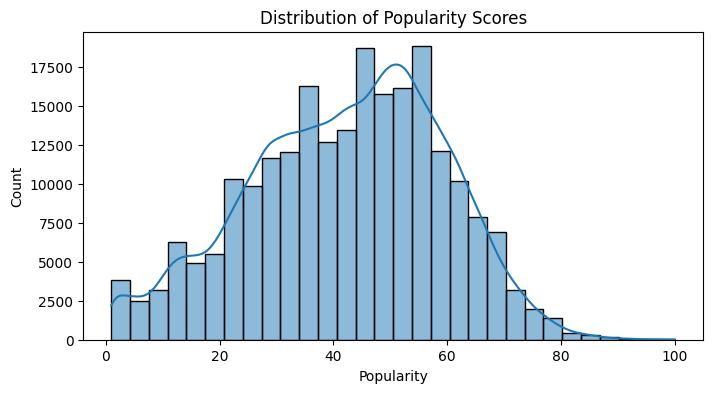

Popularity Score Percentiles:
0.25    30.0
0.50    44.0
0.75    55.0
0.90    63.0
0.95    68.0
0.99    77.0
Name: popularity, dtype: float64


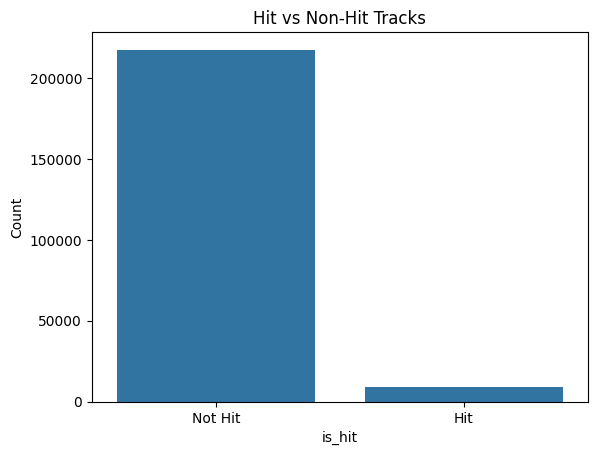

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Popularity
plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

# Percentile breakdown of popularity
popularity_percentiles = df['popularity'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print("Popularity Score Percentiles:")
print(popularity_percentiles)

# Target variable distribution (is_hit)
sns.countplot(x='is_hit', data=df)
plt.title('Hit vs Non-Hit Tracks')
plt.xticks([0,1], ['Not Hit', 'Hit'])
plt.xlabel('is_hit')
plt.ylabel('Count')
plt.show()

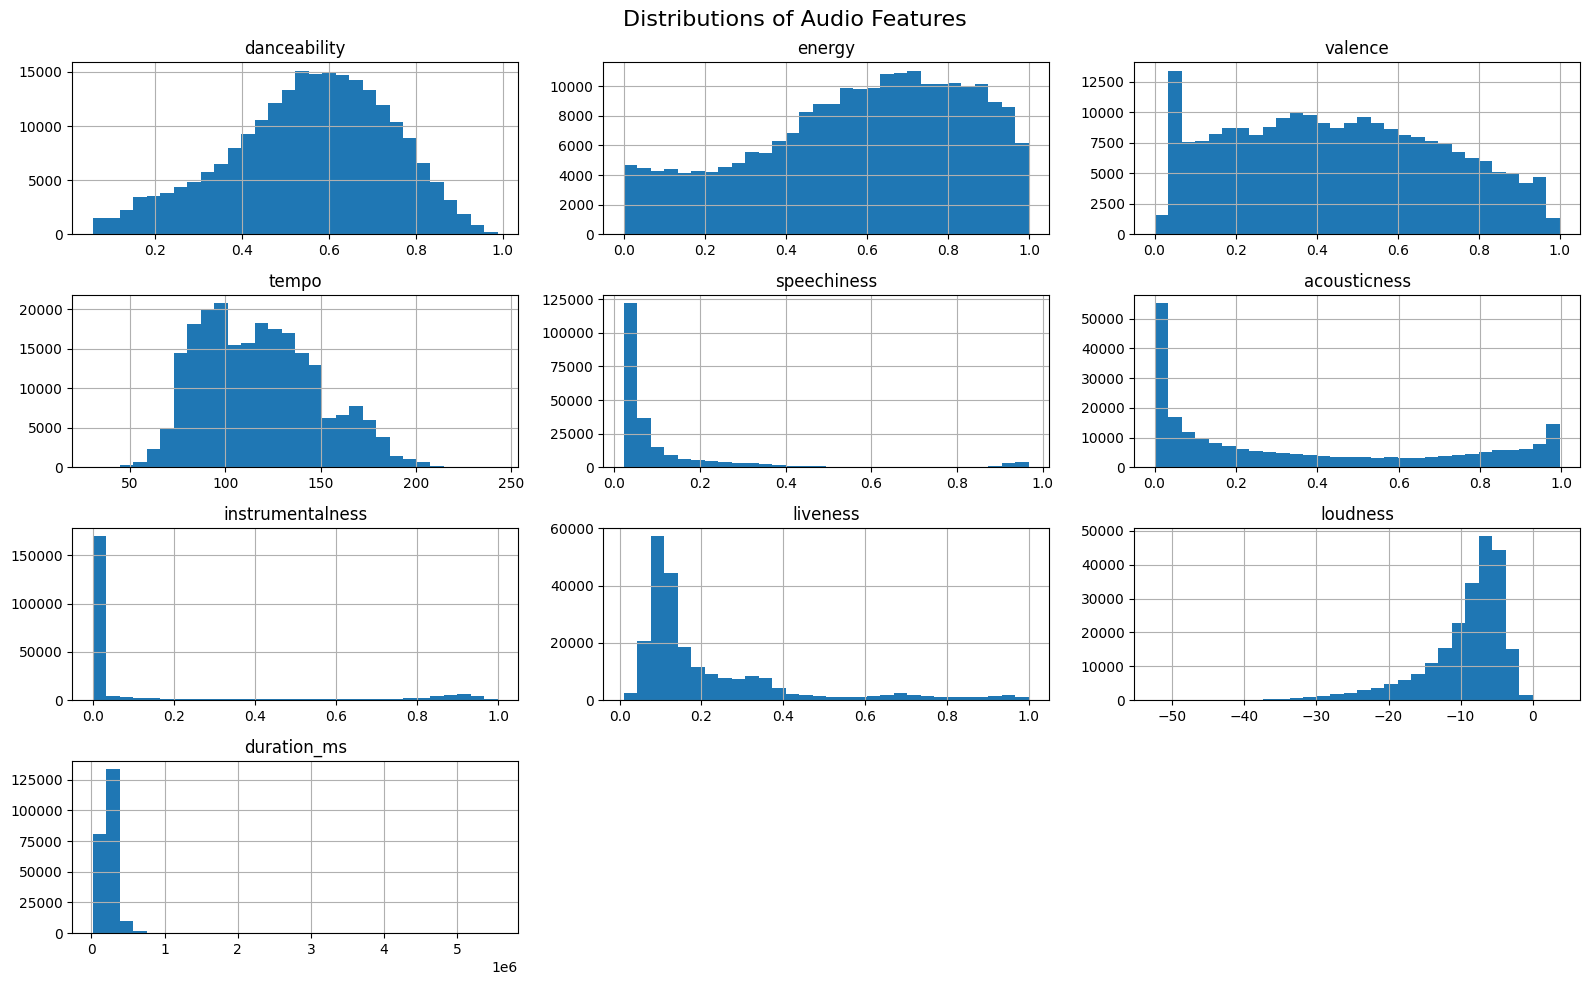

In [16]:
# Numeric feature distribution overview
numeric_cols = ['danceability', 'energy', 'valence', 'tempo', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'loudness', 'duration_ms']

df[numeric_cols].hist(bins=30, figsize=(16, 10))
plt.suptitle('Distributions of Audio Features', fontsize=16)
plt.tight_layout()
plt.show()

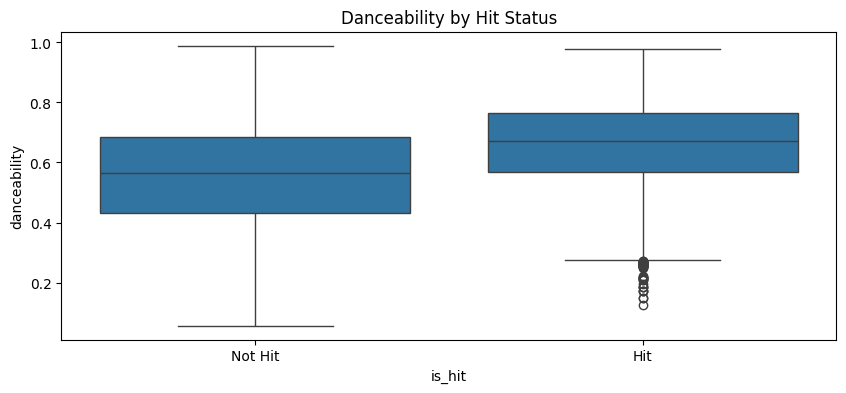

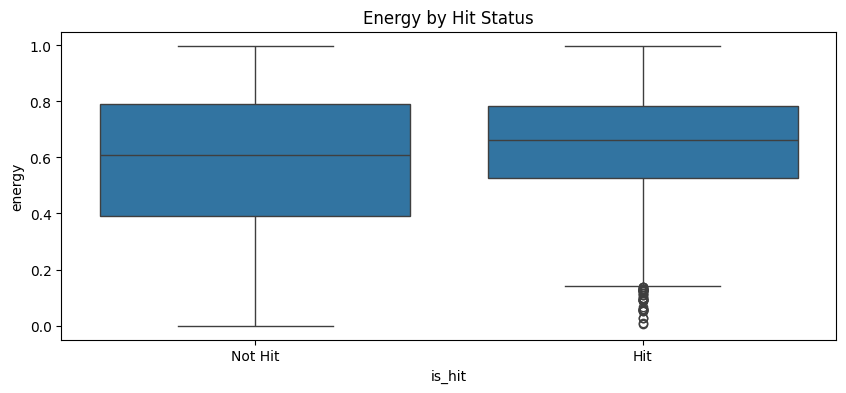

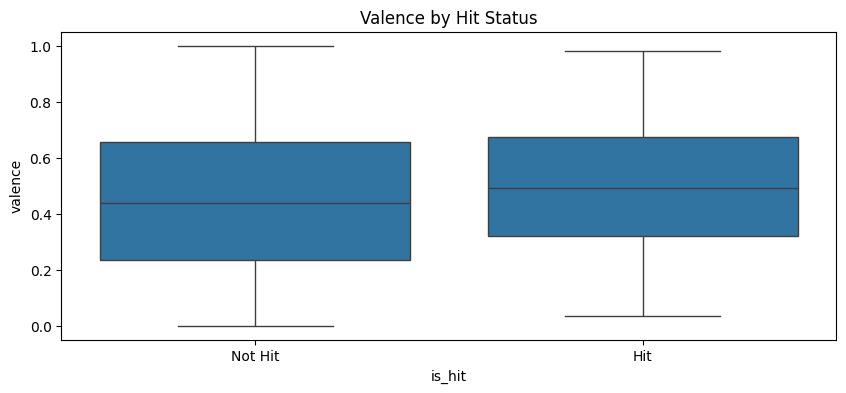

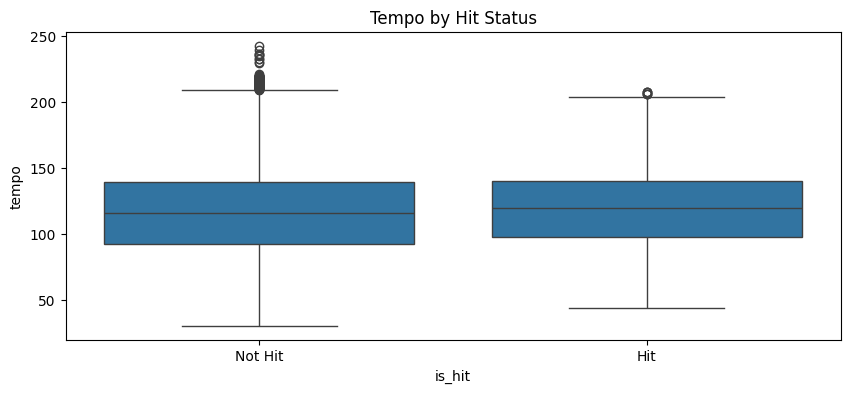

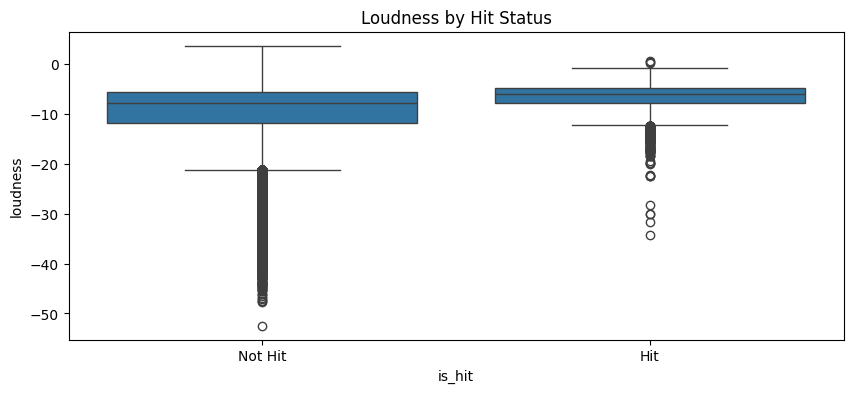

In [46]:
# Boxplots for top features split by is_hit
plt.figure(figsize=(10, 4))
sns.boxplot(x='is_hit', y='danceability', data=df)
plt.title('Danceability by Hit Status')
plt.xticks([0,1], ['Not Hit', 'Hit'])
plt.show()

for feature in ['energy', 'valence', 'tempo', 'loudness']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='is_hit', y=feature, data=df)
    plt.title(f'{feature.title()} by Hit Status')
    plt.xticks([0,1], ['Not Hit', 'Hit'])
    plt.show()

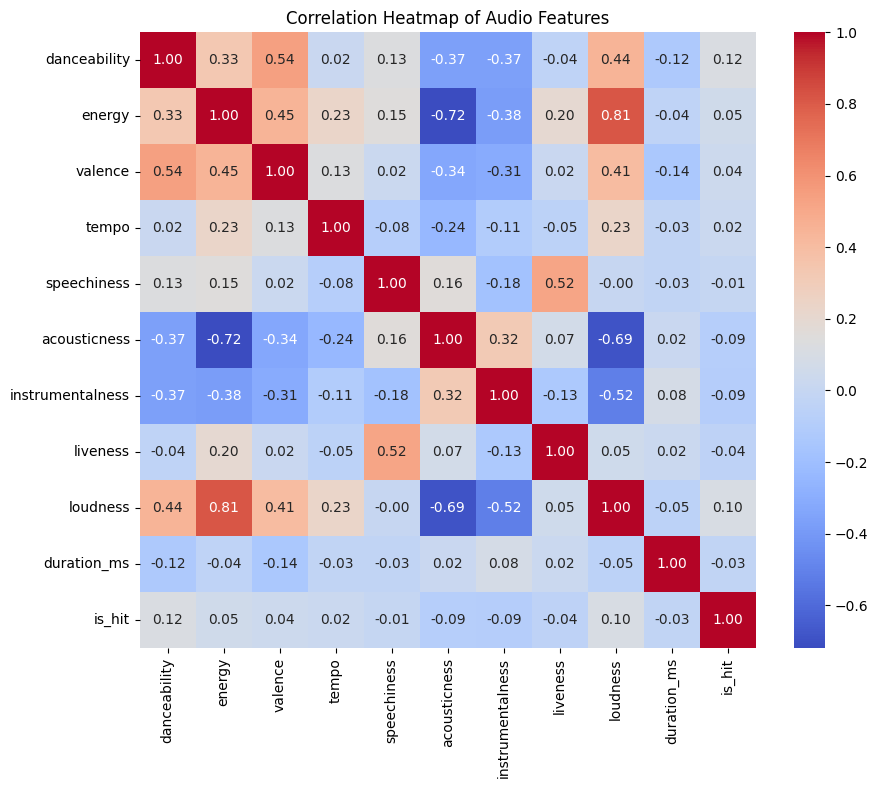

In [19]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['is_hit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Audio Features')
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
features = ['danceability', 'energy', 'valence', 'tempo', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'duration_ms']

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

In [21]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# Add to dataframe
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

print("Explained variance by component:", pca.explained_variance_ratio_)

Explained variance by component: [0.34769133 0.16313381]


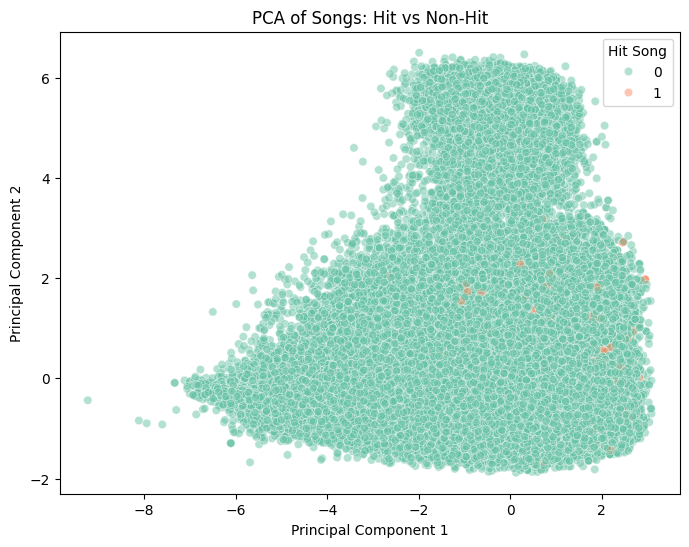

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='is_hit', palette='Set2', data=df, alpha=0.5)
plt.title('PCA of Songs: Hit vs Non-Hit')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Hit Song')
plt.show()

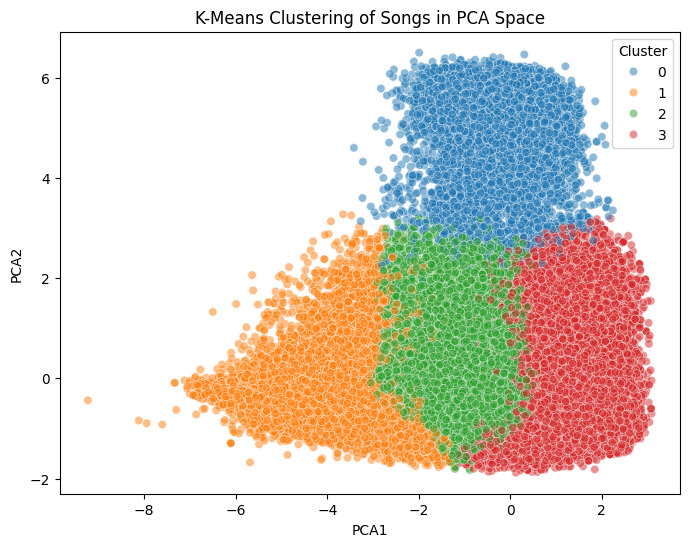

In [23]:
# Choose number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', palette='tab10', data=df, alpha=0.5)
plt.title('K-Means Clustering of Songs in PCA Space')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features and target
features = ['danceability', 'energy', 'valence', 'tempo', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'duration_ms']
target = 'is_hit'

X = df[features]
y = df[target]

# Split into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for NN (standard scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep unscaled copies for Random Forest
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 181129
Testing samples: 45283


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Define the model architecture
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),  # Helps prevent overfitting
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output: probability of being a hit
])

# 2. Compile the model
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=10, batch_size=256,
    validation_split=0.2,  # 20% of training used for validation
    verbose=1
)

2025-05-02 15:16:35.128833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 15:16:35.146893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746224195.168077  534654 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746224195.174312  534654 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-02 15:16:35.197254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-02 15:16:36.972563: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


567/567 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9150 - loss: 0.2550 - val_accuracy: 0.9609 - val_loss: 0.1483
Epoch 2/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9599 - loss: 0.1538 - val_accuracy: 0.9609 - val_loss: 0.1466
Epoch 3/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9606 - loss: 0.1499 - val_accuracy: 0.9609 - val_loss: 0.1459
Epoch 4/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9597 - loss: 0.1515 - val_accuracy: 0.9609 - val_loss: 0.1458
Epoch 5/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9604 - loss: 0.1496 - val_accuracy: 0.9609 - val_loss: 0.1452
Epoch 6/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9607 - loss: 0.1479 - val_accuracy: 0.9609 - val_loss: 0.1450
Epoch 7/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9589 - loss: 0.1514 - val_accuracy: 0.9609 - val_loss: 0.1451
Epoch 8/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9607 - loss: 0.1473 - val_accuracy: 0.9609 - val_

In [26]:
# Predict on test set
y_pred_probs = nn_model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Evaluation metrics
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs))

1416/1416 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     43483
           1       0.00      0.00      0.00      1800

    accuracy                           0.96     45283
   macro avg       0.48      0.50      0.49     45283
weighted avg       0.92      0.96      0.94     45283

Confusion Matrix:
 [[43483     0]
 [ 1800     0]]
ROC AUC Score: 0.7783992786452943


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# Rebuild the model from scratch(The accuracy was high but it may have been due to the imbalance of the data!)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

# Fit with class weights
history_balanced = nn_model.fit(
    X_train_scaled, y_train,
    epochs=10, batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5595 - loss: 0.6066 - val_accuracy: 0.5842 - val_loss: 0.5877
Epoch 2/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5717 - loss: 0.5657 - val_accuracy: 0.6072 - val_loss: 0.5767
Epoch 3/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5979 - loss: 0.5661 - val_accuracy: 0.6642 - val_loss: 0.5208
Epoch 4/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6152 - loss: 0.5583 - val_accuracy: 0.6144 - val_loss: 0.5726
Epoch 5/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6046 - loss: 0.5647 - val_accuracy: 0.6254 - val_loss: 0.5884
Epoch 6/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6142 - loss: 0.5534 - val_accuracy: 0.6162 - val_loss: 0.5783
Epoch 7/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6236 - loss: 0.5486 - val_accuracy: 0.6342 - val_loss: 0.5548
Epoch 8/10
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6140 - loss: 0.5582 - val_accuracy: 0.

In [31]:
y_pred_probs = nn_model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs))

1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.63      0.77     43483
           1       0.08      0.78      0.15      1800

    accuracy                           0.64     45283
   macro avg       0.53      0.71      0.46     45283
weighted avg       0.95      0.64      0.75     45283

Confusion Matrix:
 [[27568 15915]
 [  388  1412]]
ROC AUC Score: 0.7847234487551967


In [37]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Creating the model
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    max_depth=None,    # let trees grow fully
    random_state=42,
    class_weight='balanced'  # handles class imbalance automatically
)

# Train the model
rf_model.fit(X_train_unscaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict
y_pred_rf = rf_model.predict(X_test_unscaled)
y_prob_rf = rf_model.predict_proba(X_test_unscaled)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     43483
           1       0.95      0.81      0.88      1800

    accuracy                           0.99     45283
   macro avg       0.97      0.91      0.94     45283
weighted avg       0.99      0.99      0.99     45283

Confusion Matrix:
 [[43412    71]
 [  338  1462]]
ROC AUC Score: 0.96238257224407


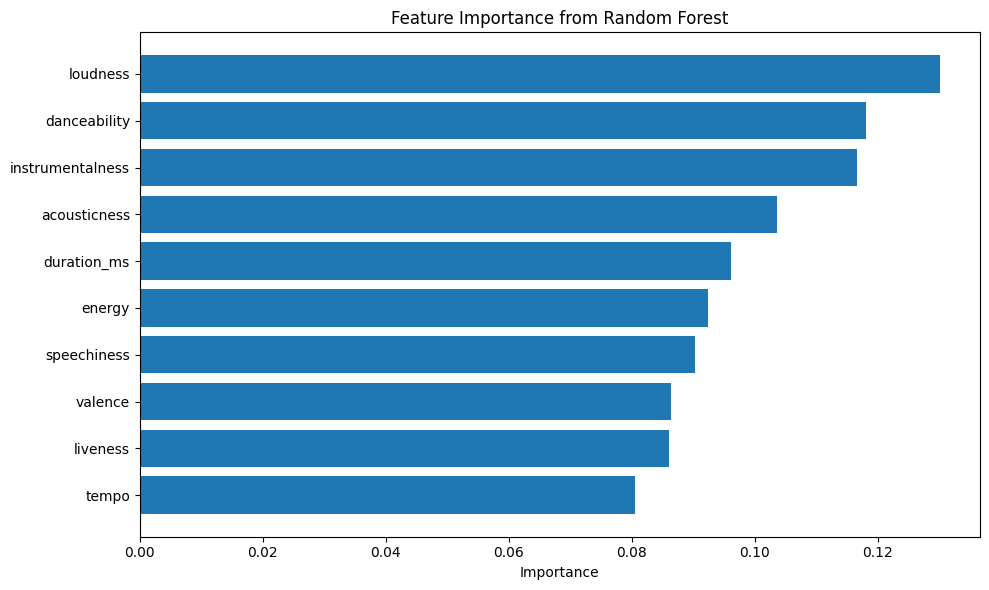

In [40]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train_unscaled.columns

# Create a sorted DataFrame
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

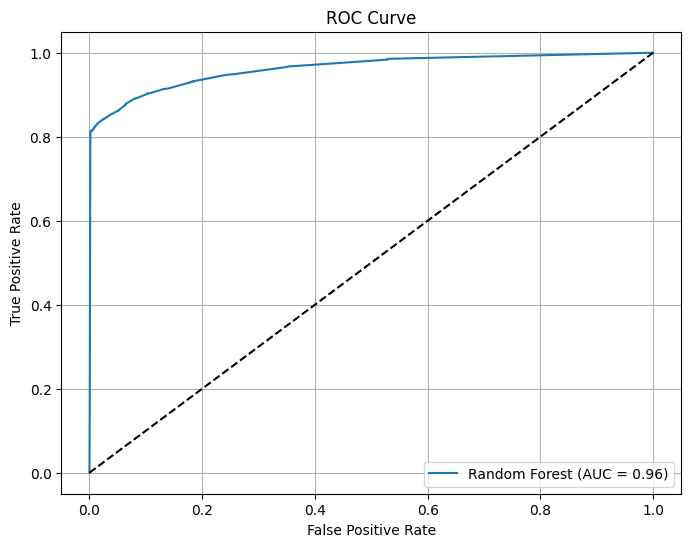

In [42]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

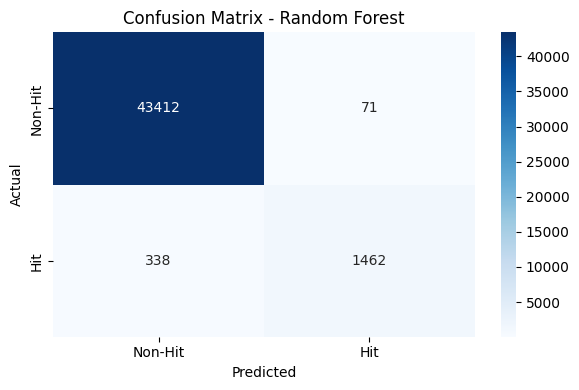

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hit', 'Hit'],
            yticklabels=['Non-Hit', 'Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()